# Notebook 04 — Phase 2: Hybrid Fusion Evaluation


## Sections
1. ASR transcript generation (faster-whisper on EMO-DB)
2. German BERT sentiment evaluation (text-only baseline)
3. 3-class acoustic collapse
4. Fusion experiments: 60/40, 75/25, 90/10
5. LR meta-learner
6. Ablation table: acoustic-only vs text-only vs each fusion variant
7. Error analysis

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression

from src.asr_pipeline import FasterWhisperASR
from src.text_classifier import GermanSentimentClassifier
from src.feature_extractor import PyAudioFeatureExtractor
from src.fusion import SentimentFusion
from src.evaluator import Evaluator
from src.label_mapper import LabelMapper
from src.utils import load_config, set_seed
from src.text_classifier import GermanEmotionClassifier

set_seed(42)
cfg = load_config('../configs/config.yaml')

EMODB_PROC     = Path('../') / cfg['data']['emodb_processed']
MANIFEST_PATH  = Path('../') / cfg['data']['emodb_manifest']
TRANSCRIPT_CSV = Path('../') / cfg['data']['emodb_transcripts']
EMODB_FEAT     = Path('../') / cfg['data']['emodb_features_overlap']
MODELS_DIR     = Path('../models/phase2')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

/home/jovyan/thesis/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[2026-04-11 19:45:33] WARNING  src.feature_extractor — pyAudioAnalysis not installed. Install from GitHub:
  pip install git+https://github.com/tyiannak/pyAudioAnalysis.git
Feature extraction will fall back to librosa-based implementation.


Setup complete.


## 1. ASR — Transcribe EMO-DB with faster-whisper (German)

In [2]:
# Load manifest
if MANIFEST_PATH.exists():
    df = pd.read_csv(MANIFEST_PATH)
    print(f'Manifest loaded: {len(df)} files')
else:
    print('⚠️  Run Notebook 02 first to build the EMO-DB manifest.')
    df = pd.DataFrame()

# Transcribe (or load cached)
if len(df) > 0:
    if TRANSCRIPT_CSV.exists():
        df_transcripts = pd.read_csv(TRANSCRIPT_CSV)
        print(f'Loaded cached transcripts: {len(df_transcripts)} entries')
        print(f'Non-null: {df_transcripts["transcript"].notna().sum()}')
    else:
        print('Transcribing EMO-DB files with faster-whisper (medium)...')
        print('⚠️  This requires ~4GB RAM for the medium model.')
        asr = FasterWhisperASR(model_size='medium', device='auto')
        filepath_col = 'processed_filepath' if 'processed_filepath' in df.columns else 'filepath'
        df_transcripts = asr.transcribe_batch(
            df, filepath_col=filepath_col, language='de',
            output_csv_path=TRANSCRIPT_CSV
        )
        print(f'Transcription complete. Saved to {TRANSCRIPT_CSV}')

Manifest loaded: 535 files
Loaded cached transcripts: 535 entries
Non-null: 535


## 2. Text-Only Baseline — German BERT

In [3]:
if 'df_transcripts' in dir() and len(df_transcripts) > 0:
    print('Loading German BERT sentiment classifier...')
    text_clf = GermanEmotionClassifier(device='auto')

    
    transcripts = df_transcripts['transcript'].fillna('').tolist()
    print(f'Predicting sentiment for {len(transcripts)} transcripts...')
    text_probas = text_clf.predict_batch(transcripts, batch_size=32)
    
    # Get 3-class true labels (collapse 7-class EMO-DB)
    true_labels_7 = df_transcripts['emotion_label_en'].values
    true_labels_3 = np.array([LabelMapper.collapse_to_3class(l) for l in true_labels_7])
    text_preds_3  = np.array([max(p, key=p.get) for p in text_probas])
    
    text_acc = accuracy_score(true_labels_3, text_preds_3)
    text_wf1 = f1_score(true_labels_3, text_preds_3, average='weighted', zero_division=0)
    text_mf1 = f1_score(true_labels_3, text_preds_3, average='macro', zero_division=0)
    
    print(f'\nText-only (German BERT) — 3-class:')
    print(f'  Accuracy:    {text_acc:.4f}')
    print(f'  Weighted F1: {text_wf1:.4f}')
    print(f'  Macro F1:    {text_mf1:.4f}')
    
    # Sample predictions
    sample_df = pd.DataFrame({'transcript': transcripts[:5], 'true': true_labels_3[:5], 'pred': text_preds_3[:5]})
    print('\nSample predictions:')
    print(sample_df)
else:
    print('⚠️  Run ASR step first.')

[2026-04-11 19:45:39] INFO     src.text_classifier — Loading Helsinki DE→EN translator...


Loading German BERT sentiment classifier...


/home/jovyan/thesis/env/lib/python3.12/site-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Loading weights: 100%|██████████| 258/258 [00:00<00:00, 64879.81it/s]
[2026-04-11 19:45:42] INFO     src.text_classifier — Loading emotion classifier: j-hartmann/emotion-english-distilroberta-base
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 23022.74it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[2026-04-11 19:45:43] INFO     src.text_classifier — GermanEmotionClassifier ready.


Predicting sentiment for 535 transcripts...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Text-only (German BERT) — 3-class:
  Accuracy:    0.2243
  Weighted F1: 0.1706
  Macro F1:    0.2278

Sample predictions:
                             transcript      true      pred
0  Der Lappen liegt auf dem Eisschrank.  positive   neutral
1  Der Lappen liegt auf dem Eisschrank.   neutral   neutral
2  Der Lappen liegt auf dem Eisschrank!  negative  positive
3     Das will sie am Mittwoch abgeben.  positive   neutral
4     Das will sie am Mittwoch abgeben.   neutral   neutral


## 3. Acoustic-Only Baseline (3-class collapsed from Phase 1 SVM)

In [4]:
import joblib
from sklearn.preprocessing import StandardScaler

if EMODB_FEAT.exists():
    X_emo, y_emo_7 = PyAudioFeatureExtractor.load_arff(EMODB_FEAT)

    assert len(X_emo) == len(df_transcripts), (
        f"ARFF has {len(X_emo)} rows but transcript CSV has {len(df_transcripts)} rows. "
        f"Re-run feature extraction (Notebook 02) to realign."
    )
    print(f'✅ Row count verified: {len(X_emo)} samples in both ARFF and transcript CSV')

    
    # Collapse 7-class to 3-class
    y_emo_3 = np.array([LabelMapper.collapse_to_3class(l) for l in y_emo_7])
    
    # Train SVM on 80%, test on 20% for held-out evaluation
    indices = np.arange(len(X_emo))
    X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
        X_emo, y_emo_3, indices,
        test_size=0.2, random_state=42, stratify=y_emo_3
    )
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    
    from sklearn.svm import SVC
    svm = SVC(C=10.0, kernel='rbf', probability=True, random_state=42)
    svm.fit(X_tr_scaled, y_tr)
    
    acoustic_probas_raw = svm.predict_proba(X_te_scaled)  # shape (n, n_classes)
    acoustic_classes = svm.classes_
    
    # Convert to list of dicts
    acoustic_probas = [
        {cls: float(prob) for cls, prob in zip(acoustic_classes, row)}
        for row in acoustic_probas_raw
    ]

    # Select text probas for the SAME test indices as acoustic split
    text_probas_te = [text_probas[i] for i in idx_te]
    print(f'Aligned test set: {len(text_probas_te)} text probas, '
          f'{len(acoustic_probas)} acoustic probas — indices match: {len(text_probas_te) == len(acoustic_probas)}')
        
    acoustic_preds = svm.predict(X_te_scaled)
    acoustic_acc = accuracy_score(y_te, acoustic_preds)
    acoustic_wf1 = f1_score(y_te, acoustic_preds, average='weighted', zero_division=0)
    acoustic_mf1 = f1_score(y_te, acoustic_preds, average='macro', zero_division=0)
    
    print(f'Acoustic-only (SVM 3-class):')
    print(f'  Accuracy:    {acoustic_acc:.4f}')
    print(f'  Weighted F1: {acoustic_wf1:.4f}')
    print(f'  Macro F1:    {acoustic_mf1:.4f}')
else:
    print('⚠️  Run Phase 1 feature extraction first (Notebook 02).')

[2026-04-11 19:46:12] INFO     src.feature_extractor — ARFF loaded: emodb_34features.arff — X=(535, 34)


✅ Row count verified: 535 samples in both ARFF and transcript CSV
Aligned test set: 107 text probas, 107 acoustic probas — indices match: True
Acoustic-only (SVM 3-class):
  Accuracy:    0.8598
  Weighted F1: 0.8594
  Macro F1:    0.8018


## 4. Ablation Study — Weighted Fusion at 60/40, 75/25, 90/10

[2026-04-11 19:46:16] INFO     src.fusion — Ablation w=0.10 → Acc=0.8692, wF1=0.8686, mF1=0.8146
[2026-04-11 19:46:16] INFO     src.fusion — Ablation w=0.25 → Acc=0.8505, wF1=0.8558, mF1=0.7985
[2026-04-11 19:46:16] INFO     src.fusion — Ablation w=0.40 → Acc=0.7664, wF1=0.7818, mF1=0.6740
[2026-04-11 19:46:16] INFO     src.fusion — Ablation w=0.60 → Acc=0.1869, wF1=0.1101, mF1=0.1922
[2026-04-11 19:46:16] INFO     src.fusion — Ablation w=0.75 → Acc=0.1869, wF1=0.1101, mF1=0.1922
[2026-04-11 19:46:16] INFO     src.fusion — Ablation w=0.90 → Acc=0.1869, wF1=0.1101, mF1=0.1922



=== Ablation Study Results ===
   text_weight  acoustic_weight  accuracy  weighted_f1  macro_f1
0         0.10             0.90    0.8692       0.8686    0.8146
1         0.25             0.75    0.8505       0.8558    0.7985
2         0.40             0.60    0.7664       0.7818    0.6740
3         0.60             0.40    0.1869       0.1101    0.1922
4         0.75             0.25    0.1869       0.1101    0.1922
5         0.90             0.10    0.1869       0.1101    0.1922


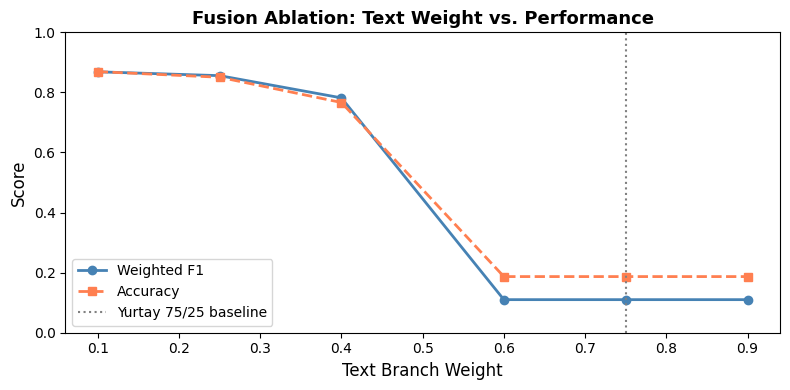

In [5]:
# This cell requires both text_probas and acoustic_probas on the same sample set
# In production: align on the test split. Here we demonstrate with available data.

if 'acoustic_probas' in dir() and 'text_probas' in dir():
    # Align samples (use the acoustic test split indices)
    # For demonstration: use min(len) samples

    
    fusion = SentimentFusion(text_weight=0.75)
    ablation_df = fusion.ablation_study(
        text_probas=text_probas_te,
        acoustic_probas=acoustic_probas,
        y_true=y_te,
        text_weights=[0.10, 0.25, 0.40, 0.60, 0.75, 0.90],

    )
    print('\n=== Ablation Study Results ===')
    print(ablation_df)
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(ablation_df['text_weight'], ablation_df['weighted_f1'], 'o-', color='steelblue', linewidth=2, label='Weighted F1')
    ax.plot(ablation_df['text_weight'], ablation_df['accuracy'], 's--', color='coral', linewidth=2, label='Accuracy')
    ax.axvline(0.75, color='gray', linestyle=':', label='Yurtay 75/25 baseline')
    ax.set_xlabel('Text Branch Weight', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Fusion Ablation: Text Weight vs. Performance', fontsize=13, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(str(MODELS_DIR / 'fusion_ablation.png'), dpi=150)
    plt.show()
else:
    print('⚠️  Complete steps 2 and 3 first.')

## 5. LR Meta-Learner

In [6]:
if 'acoustic_probas' in dir() and 'text_probas' in dir():

    X_fused = SentimentFusion.build_feature_matrix(text_probas_te, acoustic_probas)
    y_aligned = y_te
    
    # Use cross-validation on full fused test set — avoids second split on ~107 samples
    lr = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_lr = cross_val_predict(lr, X_fused, y_aligned, cv=cv)
    
    lr_acc = accuracy_score(y_aligned, y_pred_lr)
    lr_wf1 = f1_score(y_aligned, y_pred_lr, average='weighted', zero_division=0)
    lr_mf1 = f1_score(y_aligned, y_pred_lr, average='macro', zero_division=0)
        
    print('LR Meta-Learner (6-dim input):')
    print(f'  Accuracy:    {lr_acc:.4f}')
    print(f'  Weighted F1: {lr_wf1:.4f}')
    print(f'  Macro F1:    {lr_mf1:.4f}')
else:
    print('⚠️  Complete prior steps first.')

LR Meta-Learner (6-dim input):
  Accuracy:    0.8224
  Weighted F1: 0.8047
  Macro F1:    0.6978


## 6. Full Comparison Table

In [7]:
# Build the final thesis comparison table
# Populate with actual values once experiments have run

comparison = pd.DataFrame([
    {'System': 'Acoustic-only SVM',          'Dataset': 'EMO-DB (7-class)', 'Accuracy': acoustic_acc if 'acoustic_acc' in dir() else '—', 'Macro-F1': acoustic_mf1 if 'acoustic_mf1' in dir() else '—', 'Notes': 'Phase 1 baseline'},
    {'System': 'Acoustic-only SVM',          'Dataset': 'EMO-DB→RAVDESS',   'Accuracy': 0.1851, 'Macro-F1': 0.0979, 'Notes': 'Cross-corpus (see NB03)'},
    {'System': 'Text-only German BERT',      'Dataset': 'EMO-DB (3-class)', 'Accuracy': text_acc if 'text_acc' in dir() else '—', 'Macro-F1': text_mf1 if 'text_mf1' in dir() else '—', 'Notes': 'Text branch only'},
    {'System': 'Fusion 60/40',          'Dataset': 'EMO-DB (3-class)', 'Accuracy': ablation_df.loc[ablation_df['text_weight']==0.60, 'accuracy'].values[0], 'Macro-F1': ablation_df.loc[ablation_df['text_weight']==0.60, 'macro_f1'].values[0], 'Notes': 'Ablation'},
    {'System': 'Fusion 75/25 (Yurtay)', 'Dataset': 'EMO-DB (3-class)', 'Accuracy': ablation_df.loc[ablation_df['text_weight']==0.75, 'accuracy'].values[0], 'Macro-F1': ablation_df.loc[ablation_df['text_weight']==0.75, 'macro_f1'].values[0], 'Notes': 'Primary system'},
    {'System': 'Fusion 90/10',          'Dataset': 'EMO-DB (3-class)', 'Accuracy': ablation_df.loc[ablation_df['text_weight']==0.90, 'accuracy'].values[0], 'Macro-F1': ablation_df.loc[ablation_df['text_weight']==0.90, 'macro_f1'].values[0], 'Notes': 'Ablation'},
    {'System': 'Fusion LR meta-learner',     'Dataset': 'EMO-DB (3-class)', 'Accuracy': lr_acc if 'lr_acc' in dir() else '—', 'Macro-F1': lr_mf1 if 'lr_mf1' in dir() else '—', 'Notes': 'Learned weights'}
])

print('=== THESIS EVALUATION TABLE ===')
print(comparison.to_string(index=False))
comparison.to_csv(str(MODELS_DIR / 'thesis_evaluation_table.csv'), index=False)

=== THESIS EVALUATION TABLE ===
                System          Dataset  Accuracy  Macro-F1                   Notes
     Acoustic-only SVM EMO-DB (7-class)  0.859813  0.801847        Phase 1 baseline
     Acoustic-only SVM   EMO-DB→RAVDESS  0.185100  0.097900 Cross-corpus (see NB03)
 Text-only German BERT EMO-DB (3-class)  0.224299  0.227771        Text branch only
          Fusion 60/40 EMO-DB (3-class)  0.186900  0.192200                Ablation
 Fusion 75/25 (Yurtay) EMO-DB (3-class)  0.186900  0.192200          Primary system
          Fusion 90/10 EMO-DB (3-class)  0.186900  0.192200                Ablation
Fusion LR meta-learner EMO-DB (3-class)  0.822430  0.697833         Learned weights
